In [2]:
import os

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation

os.unsetenv('PROJ_LIB')

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Avenir"

path_to_scenarios = '/Users/Guille/Desktop/india_power/scenarios'
path_to_images    = '/Users/Guille/Desktop/india_power/images'
path_to_csvs      = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'

In [3]:
# Grab data from databases for plotting energy dispatch and clean energy targets
def _load_dispatch(scen_labels_):

    # Load energy dispatch table and process data from database
    def __load_dispatch_from_csv(df_, scenario, zone):
        
        df_ = df_[['period', 'timepoint', 'technology', 'load_zone', 'power_mw']]
            
        df_ = df_.groupby(['period', 
                           'timepoint',
                           'technology', 
                           'load_zone']).agg({'power_mw': 'sum'}).reset_index(drop = False)
        
        df_['scenario'] = scenario
                
        return df_
        
    # Load energy dispatch table and process data from database
    def __load_demand_from_csv(df_, scenario, zone):
                
        df_1_               = df_[['period', 'timepoint', 'load_zone', 'overgeneration_mw']].copy()
        df_1_['technology'] = 'Curtailment'                
        df_1_               = df_1_.rename(columns = {'overgeneration_mw': 'power_mw'})

        df_2_               = df_[['period',  'timepoint', 'load_zone', 'unserved_energy_mw']].copy()
        df_2_['technology'] = 'Shedding'                 
        df_2_               = df_2_.rename(columns = {'unserved_energy_mw': 'power_mw'})

        df_ = pd.concat([df_1_, df_2_], axis = 0)
            
        df_ = df_.groupby(['period', 
                           'timepoint', 
                           'technology', 
                           'load_zone']).agg({'power_mw': 'sum'}).reset_index(drop = False)
        
        df_['scenario'] = scenario
                                  
        return df_

    def __load_tx_losses_from_csv(df_, scenario, zone):
        
        df_['transmission_losses_lz_to']   = - df_['transmission_losses_lz_to'] 
        df_['transmission_losses_lz_from'] = - df_['transmission_losses_lz_from']

        df_1_               = df_[['period', 'timepoint', 'load_zone_to', 'transmission_losses_lz_to']].copy()
        df_1_['technology'] = 'Tx_Losses'
        df_1_               = df_1_.rename(columns = {'transmission_losses_lz_to': 'power_mw', 
                                                      'load_zone_to': 'load_zone'})

        df_2_               = df_[['period',  'timepoint', 'load_zone_from', 'transmission_losses_lz_from']].copy()
        df_2_['technology'] = 'Tx_Losses'
        df_2_               = df_2_.rename(columns = {'transmission_losses_lz_from': 'power_mw',
                                                      'load_zone_from': 'load_zone'})
        
        df_3_ = df_[['period', 'timepoint', 'load_zone_to', 'transmission_flow_mw']].copy()
        df_3_ = df_3_.rename(columns = {'transmission_flow_mw': 'power_mw',
                                        'load_zone_to': 'load_zone'})

        df_3_.loc[df_3_['power_mw'] >= 0., 'technology'] = 'Import'
        df_3_.loc[df_3_['power_mw'] < 0., 'technology']  = 'Export'

        
        df_4_ = df_[['period', 'timepoint', 'load_zone_from', 'transmission_flow_mw']].copy()
        df_4_ = df_4_.rename(columns = {'transmission_flow_mw': 'power_mw',
                                        'load_zone_from': 'load_zone'})

        df_4_['power_mw'] = - df_4_['power_mw']

        df_4_.loc[df_4_['power_mw'] >= 0., 'technology'] = 'Import'
        df_4_.loc[df_4_['power_mw'] < 0., 'technology']  = 'Export'

        df_ = pd.concat([df_1_, df_2_, df_3_, df_4_], axis = 0)
        
        df_ = df_.groupby(['period', 
                           'timepoint',
                           'technology', 
                           'load_zone']).agg({'power_mw': 'sum'}).reset_index(drop = False)

        df_['scenario'] = scenario
        
        return df_
        
    dfs_ = []
    # Open connection: open database and grab meta-data
    for scen, zone, path in zip(scen_labels_['scenario'], scen_labels_['zone'], scen_labels_['path']):
        print(scen, path)
        
        dir_name   = r'{}/{}'.format(path, scen)
        dispatch_  = pd.read_csv(dir_name + f'/results/project_timepoint.csv', low_memory = False)
        demand_    = pd.read_csv(dir_name + f'/results/system_load_zone_timepoint.csv', low_memory = False)
        tx_losses_ = pd.read_csv(dir_name + f'/results/transmission_timepoint.csv', low_memory = False)
        
        dfs_ += [__load_tx_losses_from_csv(tx_losses_, scen, zone)]
        dfs_ += [__load_demand_from_csv(demand_, scen, zone)]
        dfs_ += [__load_dispatch_from_csv(dispatch_, scen, zone)]
        
    return pd.concat(dfs_, axis = 0).reset_index(drop = True)

def _load_demand(scen_labels_):
    
    # Load energy dispatch table and process data from database
    def __load_demand_from_csv(df_, scenario):
  
        df_               = df_[['period', 'timepoint', 'load_zone', 'static_load_mw']].copy()
        df_               = df_.rename(columns = {'static_load_mw': 'power_mw'})
        df_['technology'] = 'Demand'                 
        df_               = df_
        df_               = df_.groupby(['period', 
                                         'timepoint',
                                         'technology', 
                                         'load_zone']).agg({'power_mw': 'sum'}).reset_index(drop = False)
        
        df_['scenario'] = scenario
                                  
        return df_
    
    dfs_ = []
    # Open connection: open database and grab meta-data
    for scen, path in zip(scen_labels_['scenario'], scen_labels_['path']):
        print(scen, path)
        
        dir_name = r'{}/{}'.format(path, scen)
        demand_  = pd.read_csv(dir_name + f'/results/system_load_zone_timepoint.csv', low_memory = False)
        
        dfs_ += [__load_demand_from_csv(demand_, scen)]

    return pd.concat(dfs_, axis = 0).reset_index(drop = True)

In [4]:
def _group_dispatch_technologies(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        idx_ = tech_labels_['group'] == group
        idx_ = df_['technology'].isin(tech_labels_.loc[idx_, 'technology'])
        df_.loc[idx_, 'technology'] = group
        
    df_ = df_.groupby(['period', 
                       'timepoint', 
                       'technology', 
                       'load_zone', 
                       'scenario']).agg({'power_mw': 'sum'})

    return df_.reset_index(drop = False)

In [20]:
# Plot energy dispatch for a given day
def _plot_zone_energy_dispatch_production(ax, df_1_, df_2_, scen_labels_, tech_labels_, scen, period, 
                                          load_zone = 'all',
                                          units     = 1e3,
                                          xlabel    = True):


    if load_zone == 'all':
        df_1_p_ = df_1_.groupby(['period', 
                                 'timepoint', 
                                 'technology', 
                                 'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)
    
        df_2_p_ = df_2_.groupby(['period', 
                                 'timepoint', 
                                 'technology', 
                                 'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)
        
        df_1_p_ = df_1_p_.loc[~df_1_p_['technology'].isin(['Export', 'Import'])].reset_index(drop = True)

    else:
        df_1_p_ = df_1_.loc[df_1_['load_zone'] == load_zone].copy()
        df_2_p_ = df_2_.loc[df_2_['load_zone'] == load_zone].copy()
    
    x_ = np.sort(df_1_p_.loc[df_1_p_['period'] == period, 'timepoint'].unique().astype(int)).astype(str)

    label = scen_labels_.loc[scen_labels_['scenario'] == scen, 'label'].to_numpy()[0]
    zone  = load_zone.replace('_', ' ')
    #title = f'{label} - {zone} - {period}'
    title = f'{label} - {period}'

    all_colors_ = []
    legend_     = []
    ys_         = []
    
    for tech in tech_labels_['group'].unique():

        idx_ = (df_1_p_['technology'] == tech) & (df_1_p_['scenario'] == scen) & (df_1_p_['period'] == period)
        x_p_ = df_1_p_.loc[idx_, 'timepoint'].to_numpy().astype(int).astype(str)
        y_   = df_1_p_.loc[idx_, 'power_mw'].to_numpy()/units
        idx_ = y_ > 0.
        
        if idx_.sum() > 0.:
            
            color = tech_labels_.loc[tech_labels_['group']== tech, 'group_color'].to_numpy()[0]
            y_p_  = np.zeros((x_.shape[0],))
            x_p_  = x_p_[idx_]
            y_    = y_[idx_]
            
            for x_p in x_p_:
                if (x_ == x_p).sum() == 1:
                    y_p_[x_ == x_p] = y_[x_p_ == x_p]

            all_colors_.append(color)
            ys_.append(y_p_)

            ax.bar(0., 0., 0., bottom    = 0. ,
                               label     = tech,
                               color     = color,
                               lw        = 0.,
                               edgecolor = "None", 
                               zorder    = 10)
            
    ax.stackplot(x_, np.vstack(ys_), colors = all_colors_, 
                                     zorder = 10, 
                                     lw     = 0.)

    all_colors_ = []
    ys_         = []
    for tech in tech_labels_['group'].unique():

        idx_ = (df_1_p_['technology'] == tech) & (df_1_p_['scenario'] == scen) & (df_1_p_['period'] == period)
        x_p_ = df_1_p_.loc[idx_, 'timepoint'].to_numpy().astype(int).astype(str)
        y_   = df_1_p_.loc[idx_, 'power_mw'].to_numpy()/units
        idx_ = y_ < 0.
        
        if idx_.sum() > 0.:

            color = tech_labels_.loc[tech_labels_['group']== tech, 'group_color'].to_numpy()[0]
            y_p_  = np.zeros((x_.shape[0],))
            x_p_  = x_p_[idx_]
            y_    = y_[idx_]

            for x_p in x_p_:
                if (x_ == x_p).sum() == 1:
                    y_p_[x_ == x_p] = y_[x_p_ == x_p]
            
            all_colors_.append(color)
            ys_.append(y_p_)
            
    if zone != 'all':
        ax.bar(0., 0., 0., bottom    = 0. ,
                           label     = 'Export',
                           color     = '#daf7a6',
                           lw        = 0.,
                           hatch     = 'xx', 
                           edgecolor = 'lightgray', 
                           zorder    = 10)

    ax.bar(0., 0., 0., bottom    = 0. ,
                       label     = 'Charge',
                       color     = 'None',
                       lw        = 0.,
                       hatch     = 'xx', 
                       edgecolor = 'lightgray', 
                       zorder    = 10)

    if len(ys_) > 0.:    
        ax.stackplot(x_, np.vstack(ys_), colors    = all_colors_, 
                                         zorder    = 10, 
                                         hatch     = 'xx', 
                                         edgecolor = 'lightgrey', 
                                         lw        = 0.)
        
    idx_  = (df_2_p_['technology'] == 'Demand') & (df_2_p_['scenario'] == scen) & (df_2_p_['period'] == period)
    load_ = df_2_p_.loc[idx_, 'power_mw'].to_numpy()/units
    
    ax.plot(x_, load_, color     = 'r', 
                       linestyle = '--', 
                       label     = 'Demand',
                       lw        = 1.75, 
                       alpha     = 1., 
                       zorder    = 11)

    ax.set_ylabel(r'Energy (GWh)', fontsize = 16)
    if xlabel: 
        ax.set_xticks(x_[::24], [x[:-2] for x in x_][::24], rotation = 45)
    else:
        ax.set_xticks(x_[::24], ['' for x in x_][::24], rotation = 45)

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12)

    ax.axhline(0, linewidth = .5, 
                  linestyle = '-', 
                  color     = 'k', 
                  clip_on   = False, 
                  zorder    = 10)

    ax.set_xlim(x_[0], x_[-1])

    ax.set_title(title, fontsize = 18)
    
    ax.grid()

In [7]:
scen_labels_ = pd.read_csv(path_to_csvs + '/cost-scenario_labels.csv') 
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 

# Electricity Dispatch per Scenario and Period

In [ ]:
demand_           = _load_demand(scen_labels_)
dispatch_         = _load_dispatch(scen_labels_)
grouped_dispatch_ = _group_dispatch_technologies(dispatch_, tech_labels_)

In [1]:
scen   = 'VREhigh_SThigh_CONVhigh_H2_RES_10PRM_CC_50RPS_90CAP_500GW_PIERmid'
period = 2050
zone   = 'Uttar_Pradesh'

fig = plt.figure(figsize = (25, 4))
_ax = plt.subplot(111)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax, grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scen, period, zone,
                                      legend = True, 
                                      xlabel = False)
    
plt.savefig(path_to_images + f'/{zone}-{scen}-dispath_plot.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

NameError: name 'plt' is not defined

# Mosaic

In [9]:
demand_           = _load_demand(scen_labels_)
dispatch_         = _load_dispatch(scen_labels_)
grouped_dispatch_ = _group_dispatch_technologies(dispatch_, tech_labels_)

VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenario

### Different Periods per Scenario

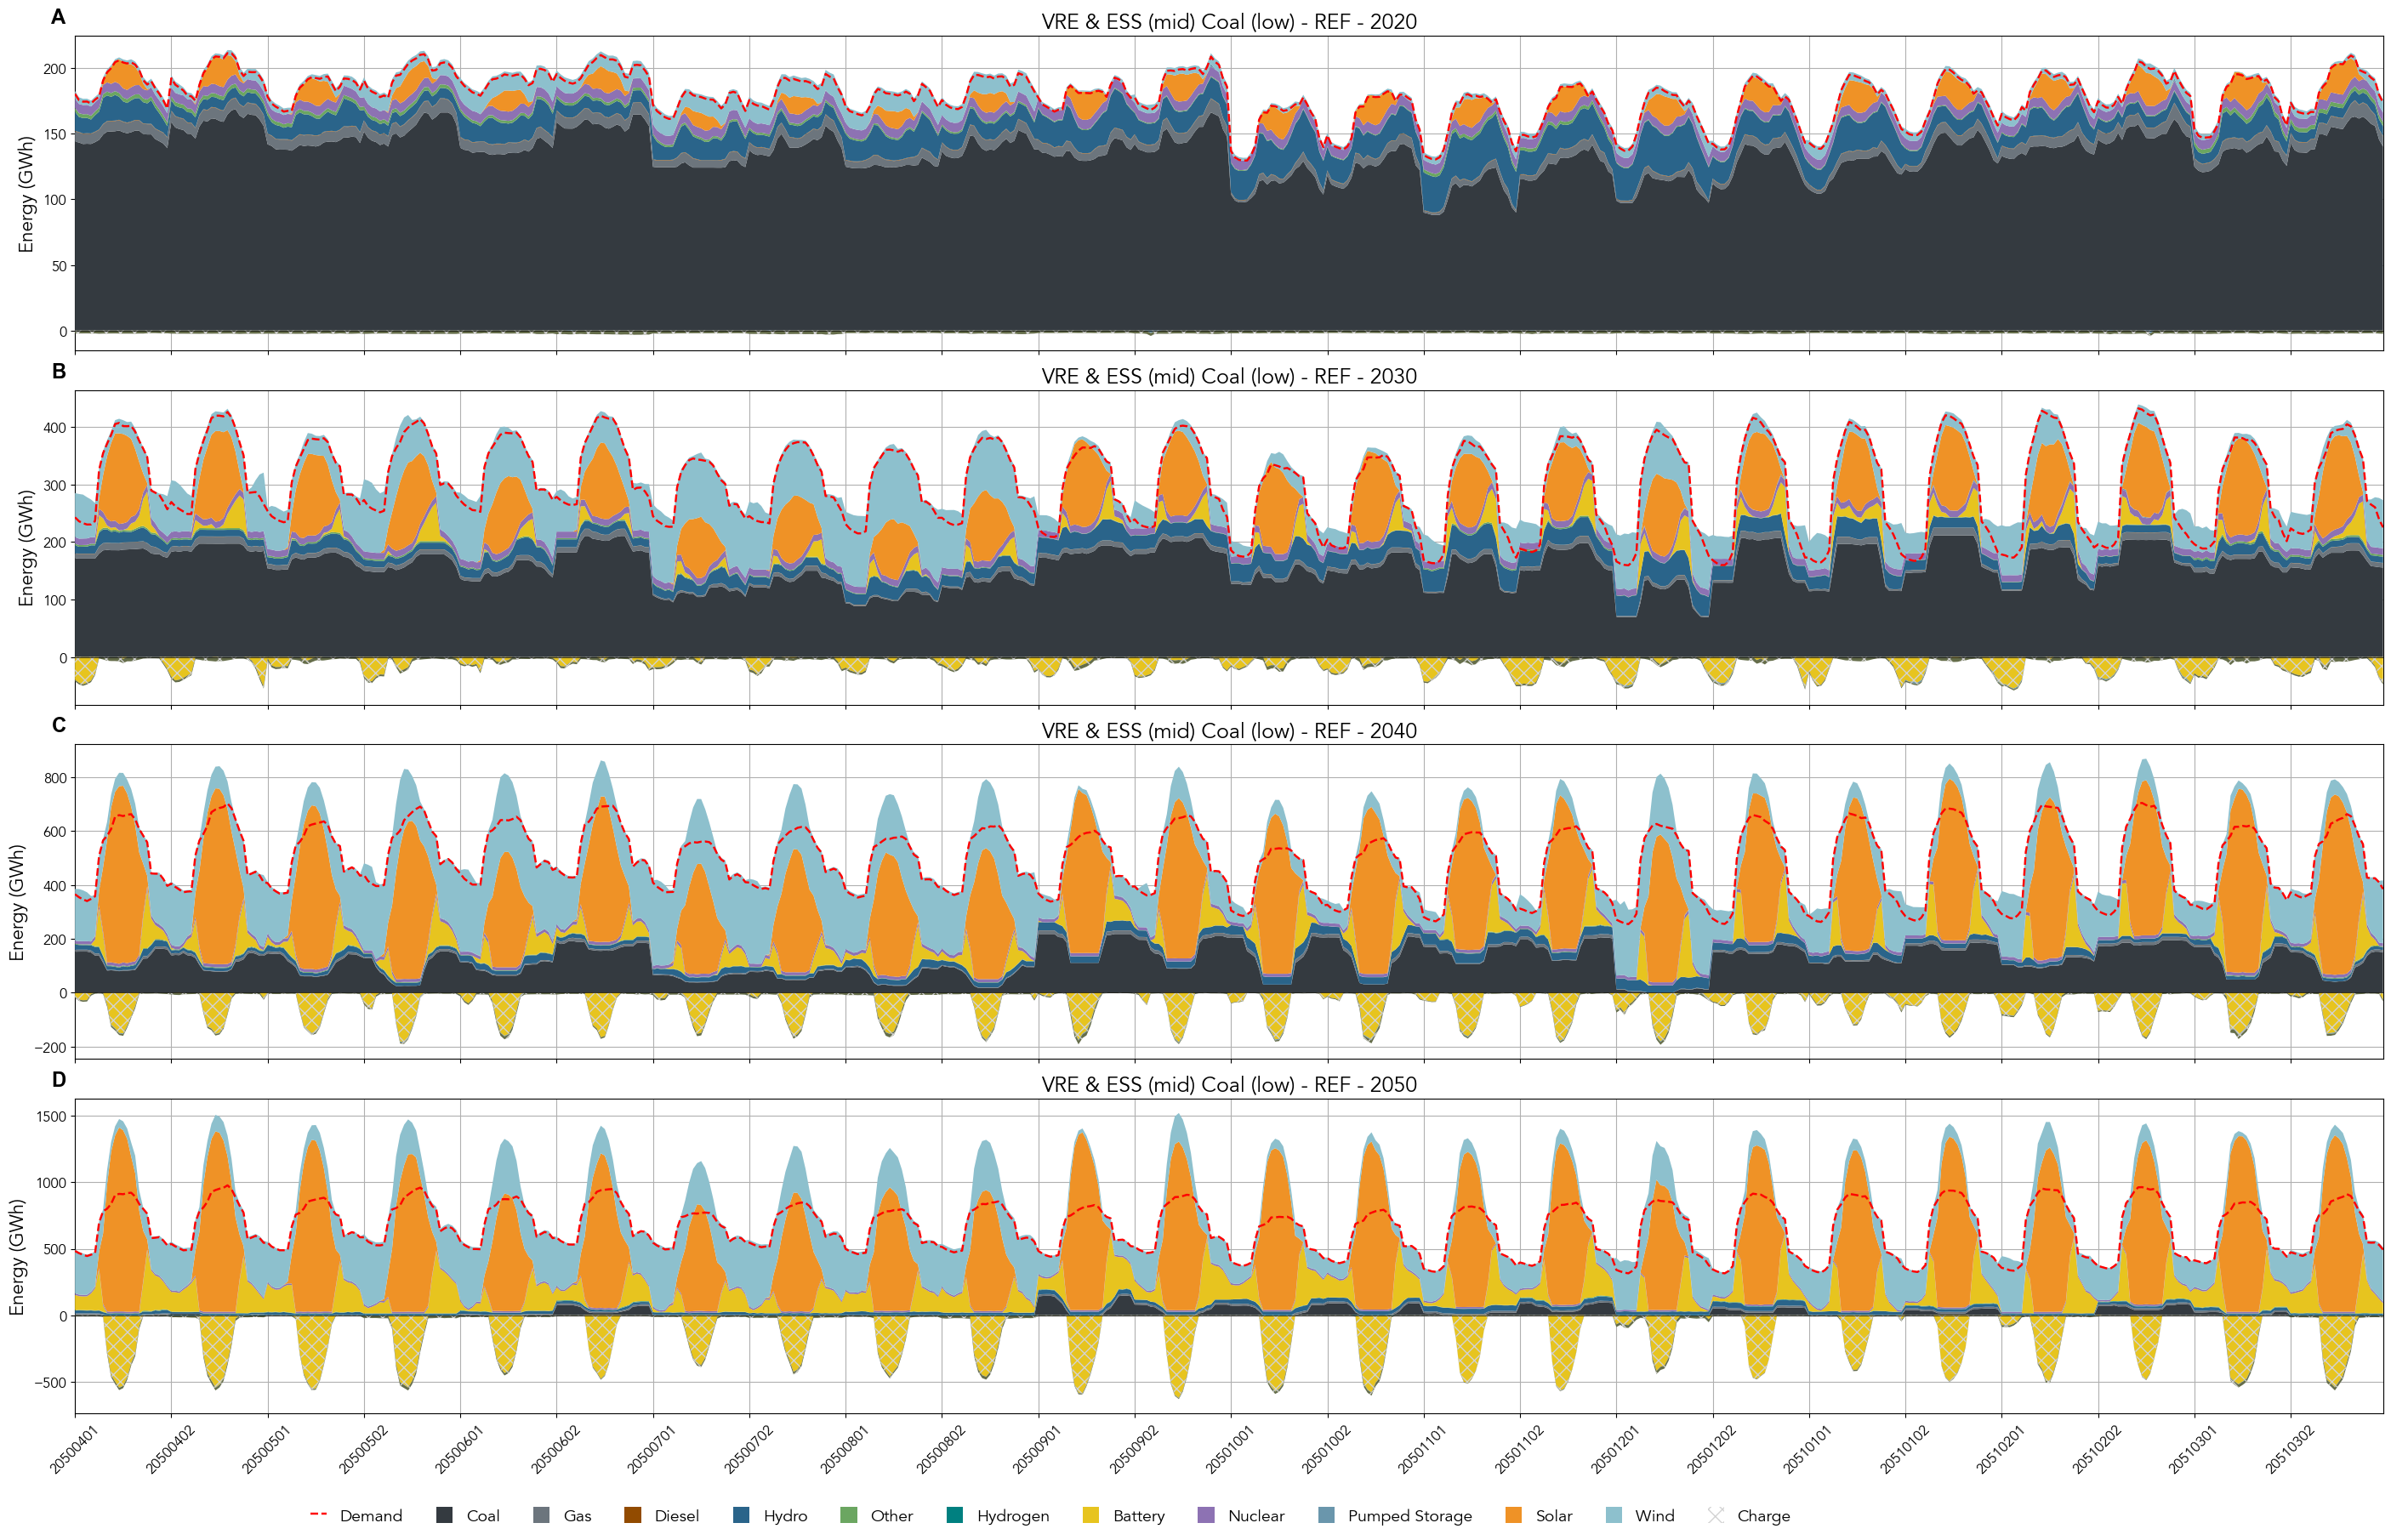

In [22]:
scen     = 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
zone     = 'all'
periods_ = np.sort(demand_['period'].unique())

fig, _ax = plt.subplot_mosaic([['A'], 
                               ['B'], 
                               ['C'],
                               ['D']], layout      = 'constrained', 
                                       figsize     = (28, 18), 
                                       gridspec_kw = {'width_ratios': [1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                             fontsize  = 'xx-large', 
                             weight    = "bold",
                             va        = 'bottom',
                             family    = 'Arial')

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['A'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scen, periods_[0], zone,
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['B'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scen, periods_[1], zone,
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['C'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scen, periods_[2], zone,
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['D'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scen, periods_[3], zone,
                                      xlabel = True)

_ax['D'].legend(bbox_to_anchor = (.75, -0.25),
                frameon        = False,
                ncol           = 15,
                prop           = {'size': 14})
    
plt.savefig(path_to_images + f'/SI-system_level-dispatch_plot-{scen}.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + f'/SI-system_level-dispatch_plot-{scen}.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

### Different Scenarios per Period

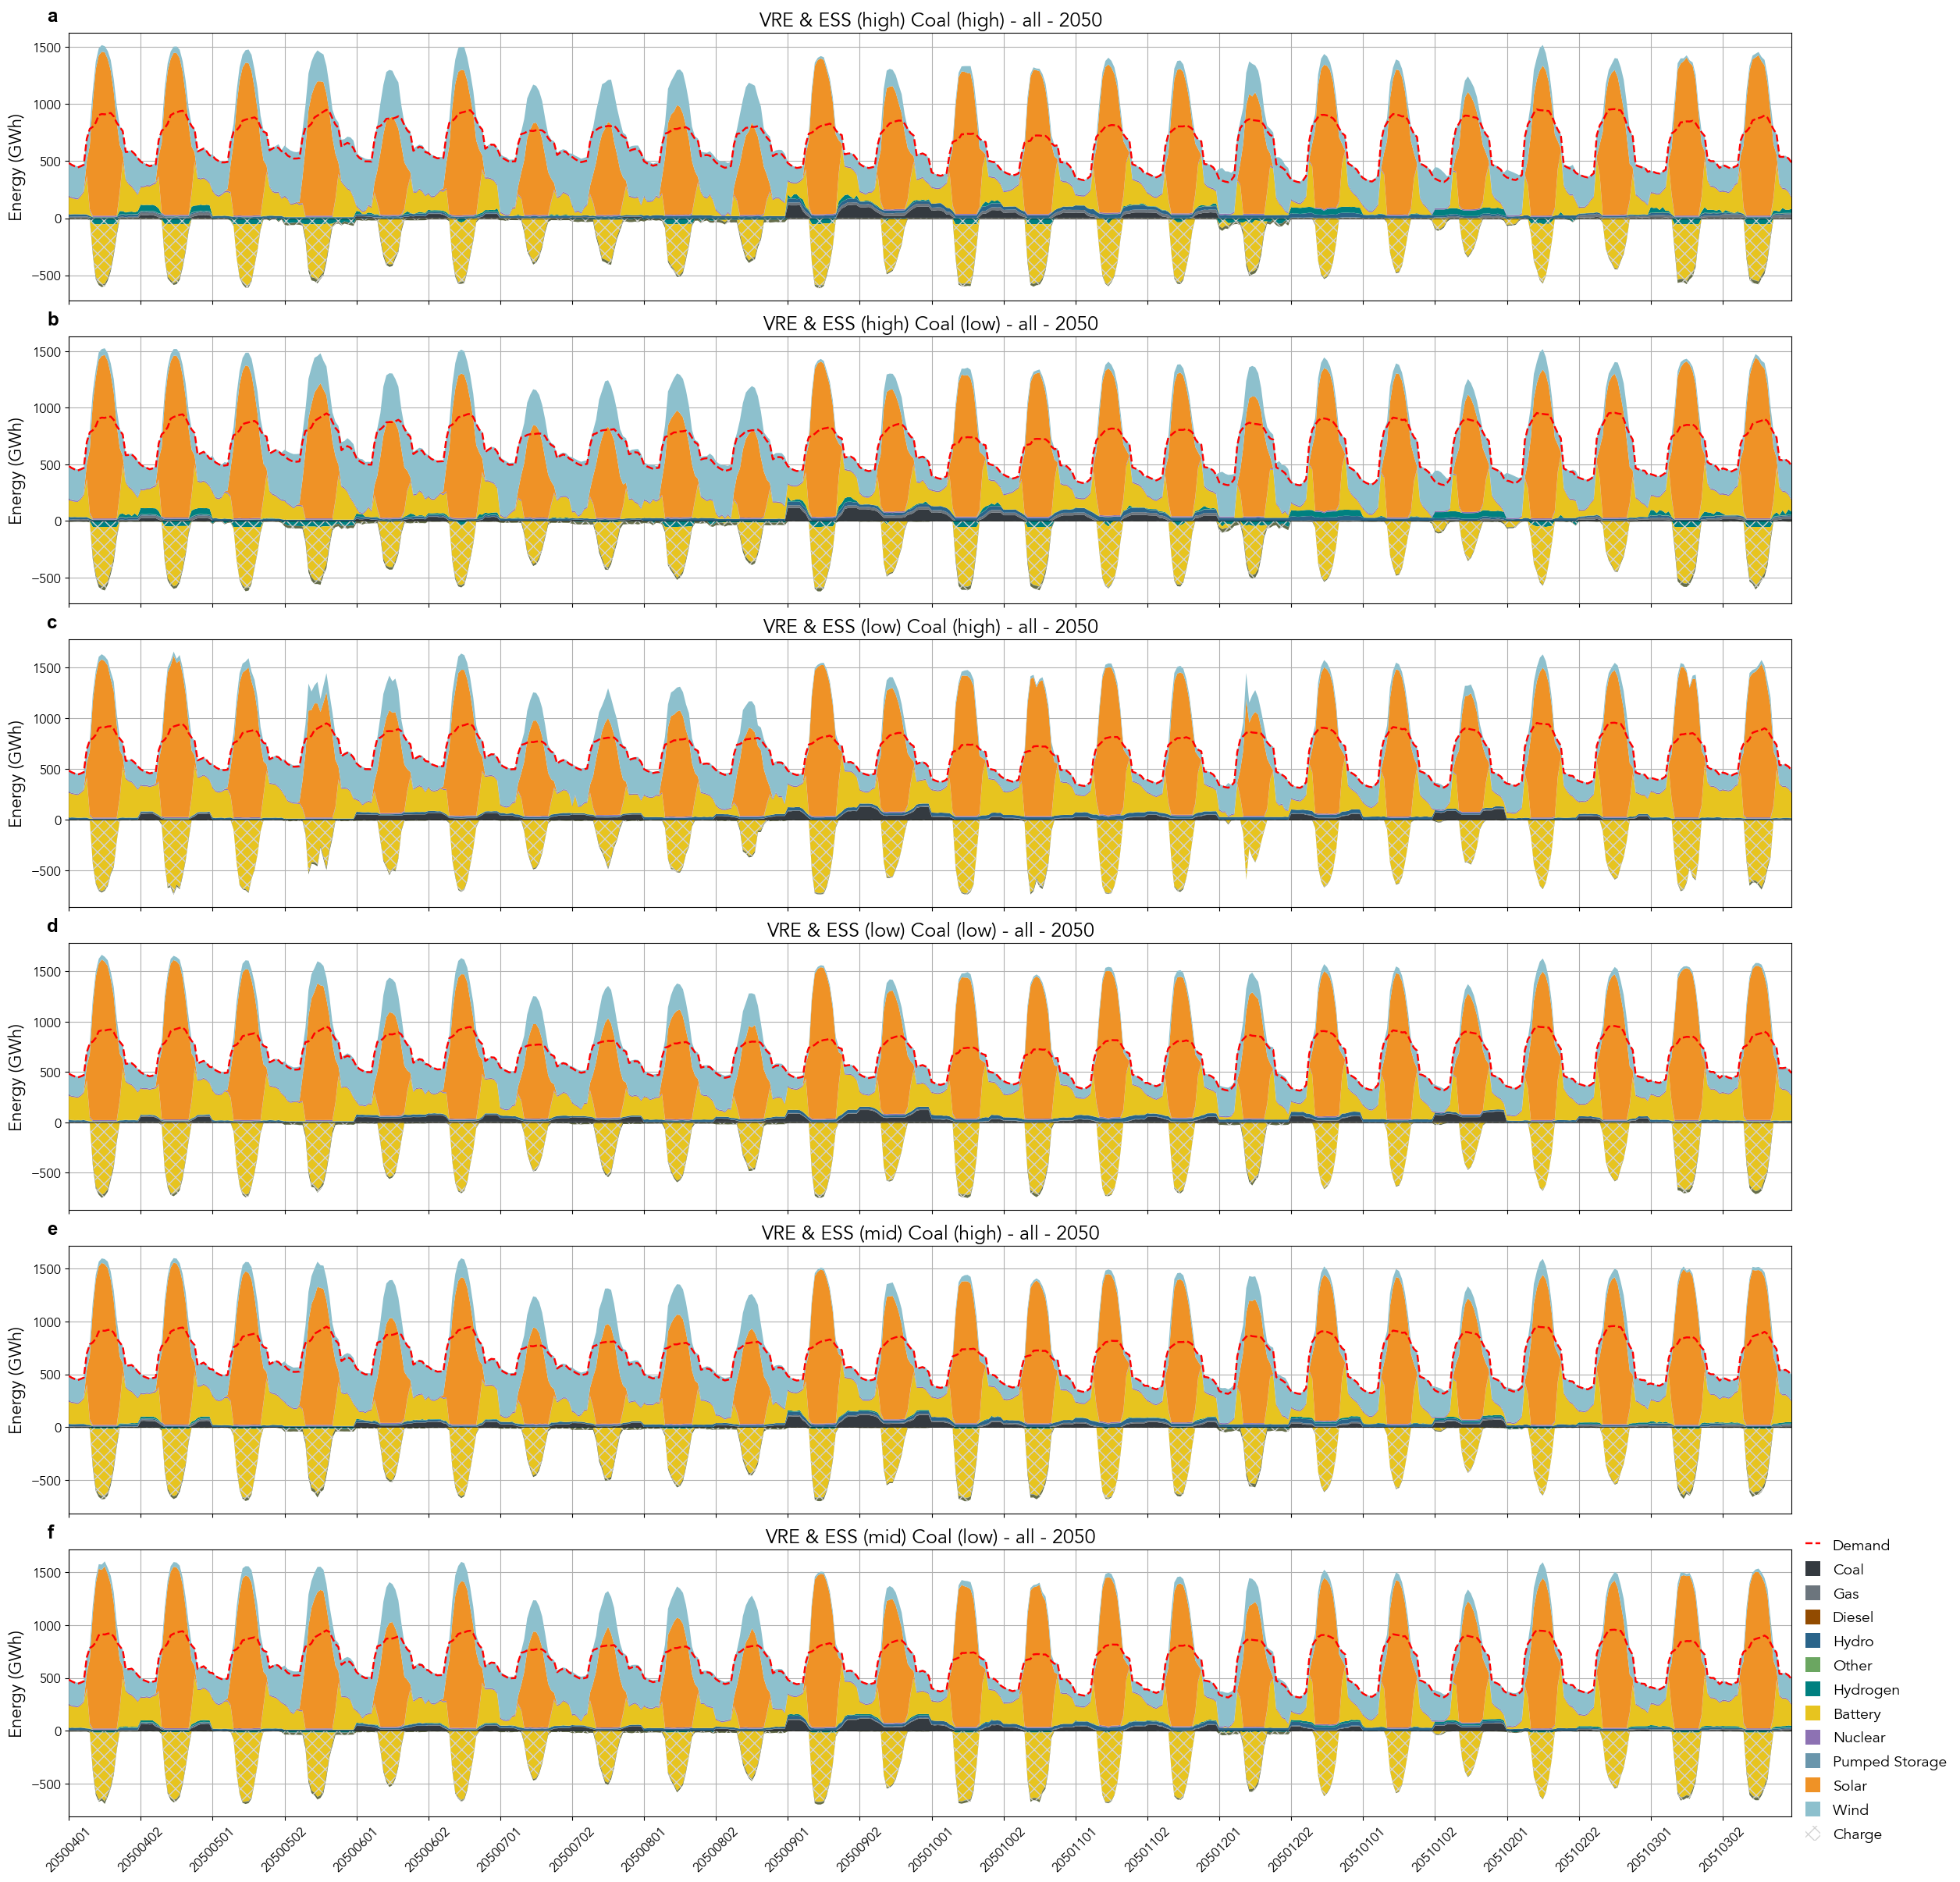

In [263]:
period = 2050
zone   = 'all'
scens_ = np.sort(demand_['scenario'].unique())

fig, _ax = plt.subplot_mosaic([['a'], 
                               ['b'], 
                               ['c'], 
                               ['d'], 
                               ['e'], 
                               ['f']], layout      = 'constrained', 
                                       figsize     = (25, 24), 
                                       gridspec_kw = {'width_ratios': [1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                             fontsize  = 'xx-large', 
                             weight    = "bold",
                             va        = 'bottom',
                             family    = 'Arial')

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['a'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scens_[0], period, zone,
                                      legend = False,
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['b'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scens_[1], period, zone,
                                      legend = False, 
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['c'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scens_[2], period, zone,
                                      legend = False, 
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['d'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scens_[3], period, zone,
                                      legend = False, 
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['e'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scens_[4], period, zone,
                                      legend = False, 
                                      xlabel = False)

# Plot energy dispatch for a given day
_plot_zone_energy_dispatch_production(_ax['f'], grouped_dispatch_, demand_, scen_labels_, tech_labels_, 
                                      scens_[5], period, zone,
                                      legend = True, 
                                      xlabel = True)

plt.savefig(path_to_images + f'/{zone}-{period}-dispatch_plot.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()